# Data Analysis

In [139]:
library(dplyr)
library(car)
library(ggplot2)

In [140]:
dataset_url <- "https://raw.githubusercontent.com/wilkmzhou/STAT306_PROJECT_REPORT_2026/refs/heads/main/mercedes_benz_listings_cleaned.csv"

benzDataRaw <- read.csv(dataset_url)
head(benzDataRaw, n = 3)

,Vehicle_Name,Year,Vehicle_Age,Model_Series,Trim_Level,Body_Type,Is_AMG,Is_4MATIC,Mileage_Miles,Mileage_Category,Price_USD,Price_Category,Price_Per_Mile
,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,<chr>,<dbl>
1,2025 Mercedes-Benz AMG S 63 E 4MATIC,2025,1,AMG S 63,S 63,Other,1,1,9860,Low (< 20K),151900,Luxury (> $70K),15.405680
2,2025 Mercedes-Benz GLE 580 4MATIC,2025,1,GLE,E 580,SUV,0,1,3154,Low (< 20K),82975,Luxury (> $70K),26.307863
3,2025 Mercedes-Benz GLS 450 4MATIC,2025,1,GLS,S 450,SUV,0,1,15496,Low (< 20K),75500,Luxury (> $70K),4.872225


In [141]:
benzData <- benzDataRaw |> 
    na.omit() |>                                                                                              # remove any NA rows 
    select(-Price_Per_Mile, -Price_Category, -Year, -Mileage_Category, -Vehicle_Name, -Model_Series, -Is_AMG) # remove redundant variables
head(benzData, n = 3)

,Vehicle_Age,Trim_Level,Body_Type,Is_4MATIC,Mileage_Miles,Price_USD
,<int>,<chr>,<chr>,<int>,<int>,<int>
1,1,S 63,Other,1,9860,151900
2,1,E 580,SUV,1,3154,82975
3,1,S 450,SUV,1,15496,75500


## Exploratory Data Analysis
### Numerical Variables

,Vehicle_Age,Is_4MATIC,Mileage_Miles,Price_USD
Vehicle_Age,1.0000000,-0.20408236,0.78953619,-0.51722874
Is_4MATIC,-0.2040824,1.00000000,0.01603375,-0.01286237
Mileage_Miles,0.7895362,0.01603375,1.00000000,-0.54784996
Price_USD,-0.5172287,-0.01286237,-0.54784996,1.00000000


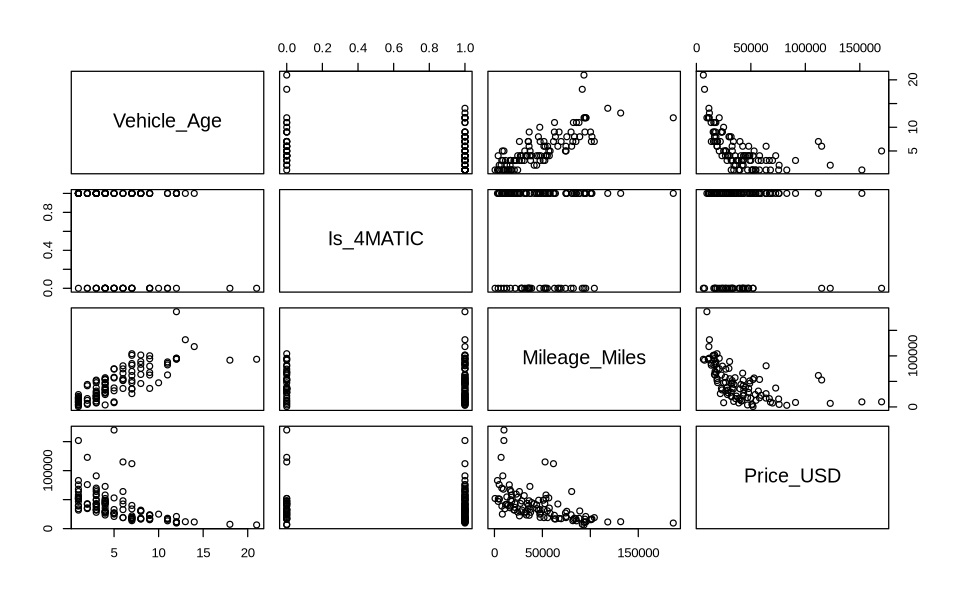

In [142]:
benzDataInt <- benzData |>
    select(-Trim_Level, -Body_Type) # filter dataset from categorical variables

pairs(benzDataInt) # scatterplot between each pair of numerical variables
cor(benzDataInt) # correlation between each pair of numerical variables

### Categorical Variables

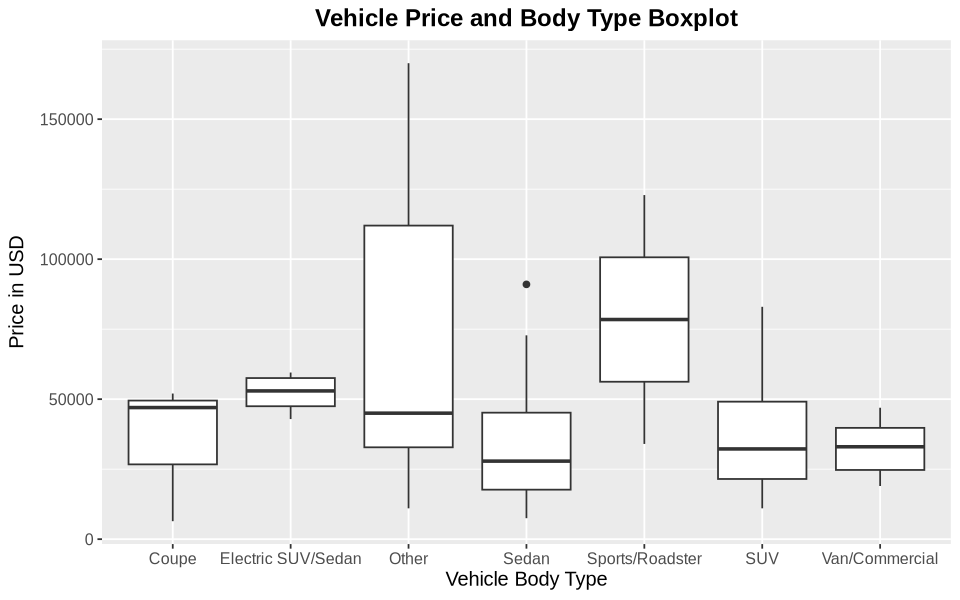

In [143]:
options(repr.plot.width = 8, repr.plot.height = 5)
benzDataCat <- benzData |>
    select(-Vehicle_Age, -Is_4MATIC, -Mileage_Miles) # filter dataset from numerical variables

benzBodyBoxplot <- benzDataCat |>
    ggplot(aes(x = Body_Type, y = Price_USD)) + 
    geom_boxplot() + 
    ylab("Price in USD") + # y-axis label change 
    xlab("Vehicle Body Type") + # x-axis label change
    ggtitle("Vehicle Price and Body Type Boxplot") + # title
    theme(plot.title = element_text(hjust = 0.5, face = "bold"), text = element_text(size = 12)) # title alignment and text size increase

benzBodyBoxplot

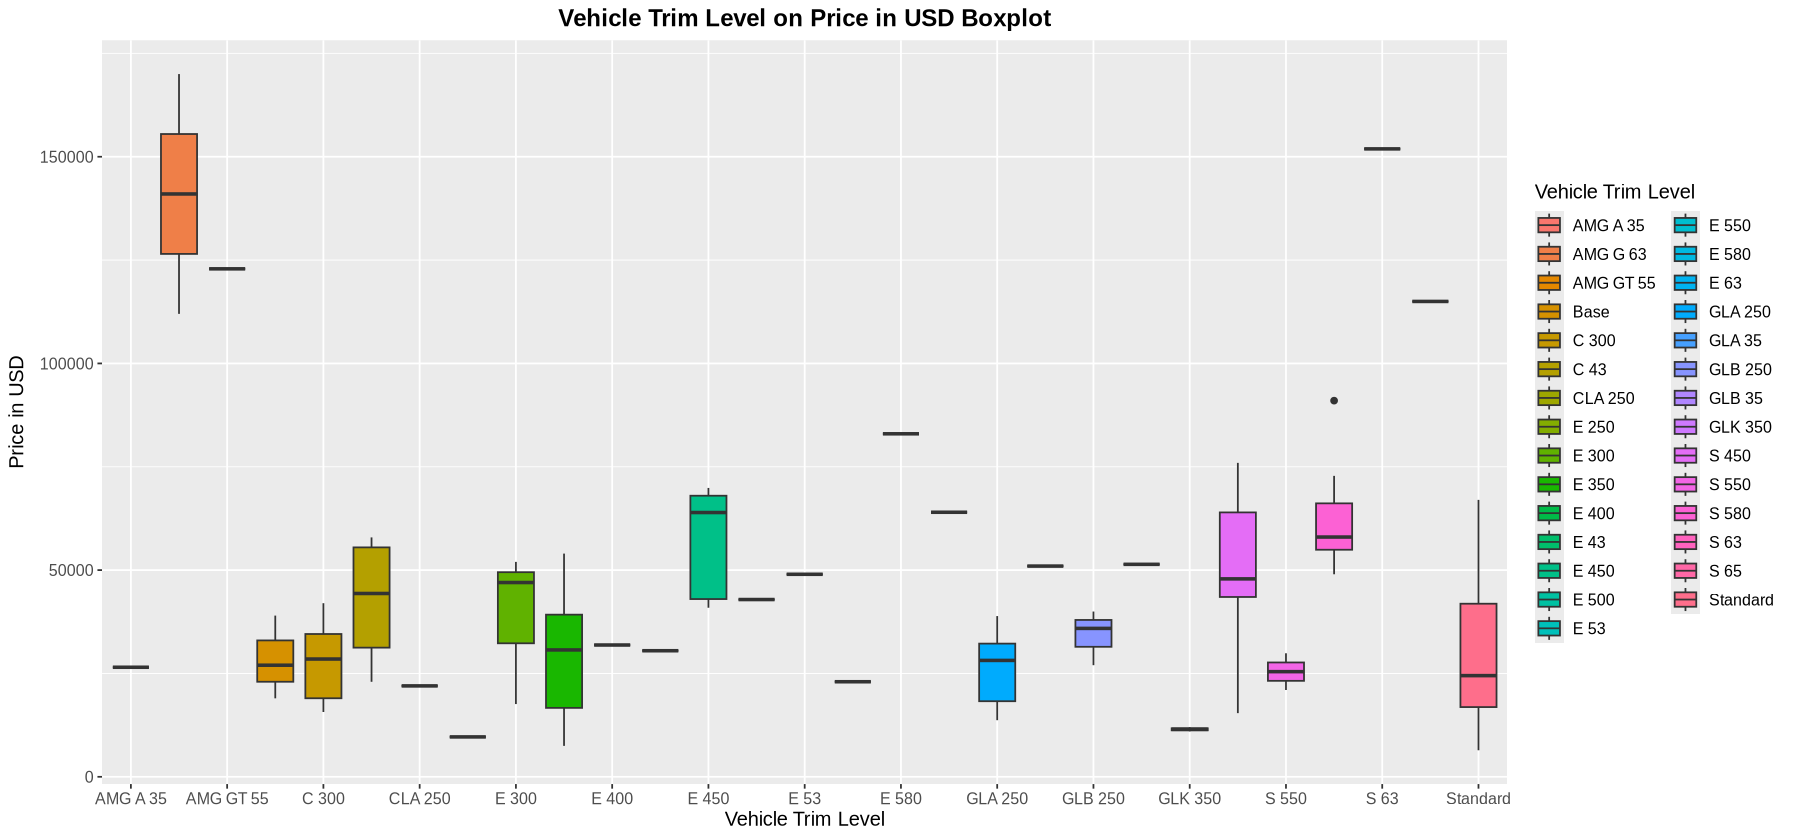

In [144]:
options(repr.plot.height = 7, repr.plot.width = 15)
benzDataCat$Trim_Level <- factor(benzDataCat$Trim_Level)
benzTrimBoxplot <- benzDataCat |>
    ggplot(aes(x = Trim_Level, y = Price_USD, fill = Trim_Level)) +
    geom_boxplot() +
    labs(x = "Vehicle Trim Level", y = "Price in USD", fill = "Vehicle Trim Level") + # label change
    ggtitle("Vehicle Trim Level on Price in USD Boxplot") + # add title 
    theme(plot.title = element_text(hjust = 0.5, face = "bold"), text = element_text(size = 12)) + # adjustments to title and text size
    scale_x_discrete(breaks = levels(benzDataCat$Trim_Level)[seq(1, 29, by = 2)]) # show x-axis indices every two categories

benzTrimBoxplot

### Fitting Linear Regression Model

In [145]:
benzFit1 <- lm(Price_USD ~ ., data = benzData) # fit linear regression model with all variables in filtered dataset

summary(benzFit1) # print linear regression fit statistics


Call:
lm(formula = Price_USD ~ ., data = benzData)

Residuals:
   Min     1Q Median     3Q    Max 
-20209  -2573      0   2358  20791 

Coefficients:
                              Estimate Std. Error t value Pr(>|t|)    
(Intercept)                  6.515e+04  1.255e+04   5.193 1.94e-06 ***
Vehicle_Age                 -1.595e+03  4.727e+02  -3.375  0.00121 ** 
Trim_LevelAMG G 63           1.087e+05  1.003e+04  10.829  < 2e-16 ***
Trim_LevelAMG GT 55          7.463e+04  1.572e+04   4.747 1.06e-05 ***
Trim_LevelBase              -5.061e+03  1.193e+04  -0.424  0.67282    
Trim_LevelC 300             -9.789e+03  9.774e+03  -1.002  0.32002    
Trim_LevelC 43               1.540e+03  1.061e+04   0.145  0.88505    
Trim_LevelCLA 250           -1.588e+04  1.263e+04  -1.257  0.21281    
Trim_LevelE 250              2.415e+04  1.367e+04   1.767  0.08166 .  
Trim_LevelE 300             -9.528e+03  1.190e+04  -0.801  0.42603    
Trim_LevelE 350             -6.714e+02  9.968e+03  -0.067  0.94650  

### Residuals and Fitted Values Scatterplot

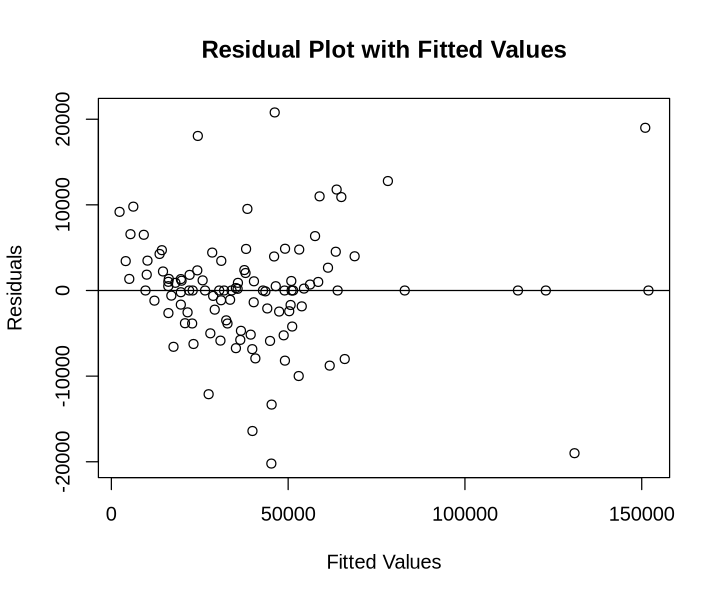

In [150]:
options(repr.plot.width = 6, repr.plot.height = 5)
plot(fitted(benzFit1), resid(benzFit1), main = "Residual Plot with Fitted Values", xlab = "Fitted Values", ylab = "Residuals") # plot fitted values and residuals
abline(0,0)                                                                         # add horizontal line at 0 
